# 🚀 Practice Day 23

**📅 Date:** 2026-10-04  
**📁 Category:** Phase 3 · 시각화 스토리텔링(Seaborn) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Use Seaborn to visually tell the story of what drives home prices — size, location, and proximity to transit
  (Seaborn으로 무엇이 집값을 좌우하는지 — 평수·지역·역세권 여부 — 시각적으로 스토리텔링하기)
- Quantify how strongly size correlates with price, how prices differ across neighborhoods, and whether subway distance still matters once size is accounted for
  (평수와 가격의 상관관계, 지역별 가격 차이, 평당 가격 기준 지하철 거리의 영향을 정량적으로 파악하기)

---
# 📂 Dataset

**Dataset Name:** Rivermoor Realty — Listing Data / Rivermoor 부동산 — 매물 데이터

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** 300 apartment listings (single table) across 6 New York City neighborhoods (SoHo, Midtown, Chelsea, Williamsburg, Astoria, Forest Hills). Includes size (sqm), bedroom count, building age, distance to the nearest subway station (km), and price (USD). Clean — no missing values or duplicates. Several variables jointly shape price, so the focus is on using Seaborn to visualize those relationships and build a narrative.
(300건의 아파트 매물 데이터(단일 테이블)로, 뉴욕 6개 동네(SoHo/Midtown/Chelsea/Williamsburg/Astoria/Forest Hills)에 걸쳐 있습니다. 면적(sqm), 침실 수, 건물 연식, 지하철역까지 거리(km), 가격(USD)을 포함하며 결측치·중복 없이 깨끗합니다. 여러 변수가 함께 가격에 영향을 미치는 구조라, Seaborn으로 관계를 시각화하며 스토리를 풀어가는 데 초점을 둡니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)
rng = np.random.default_rng(42)

# --- Generate apartment listings across 6 neighborhoods ---
n = 300
neighborhoods = ['SoHo', 'Midtown', 'Chelsea', 'Williamsburg', 'Astoria', 'Forest Hills']
neighborhood_w = [0.12, 0.15, 0.18, 0.18, 0.19, 0.18]
base_price_per_sqm = {'SoHo': 11_000, 'Midtown': 9_500, 'Chelsea': 8_000,
                       'Williamsburg': 7_500, 'Astoria': 6_500, 'Forest Hills': 5_500}

neigh = rng.choice(neighborhoods, size=n, p=neighborhood_w)
size_sqm = np.clip(rng.normal(65, 20, n), 25, 130).round(1)
bedrooms = np.clip(np.round(size_sqm / 28 + rng.normal(0, 0.4, n)), 1, 5).astype(int)
age_years = rng.integers(0, 36, n)
distance_to_subway_km = np.clip(rng.exponential(0.8, n), 0.05, 3.8).round(2)

noise = rng.normal(1.0, 0.06, n)
price = np.array([base_price_per_sqm[nb] for nb in neigh]) * size_sqm \
        * (1 - 0.14 * distance_to_subway_km) * (1 - 0.004 * age_years) * noise
price = (price / 1_000).round().astype(int) * 1_000  # round to nearest thousand USD

df = pd.DataFrame({
    'listing_id': [f'L{str(i+1).zfill(3)}' for i in range(n)],
    'neighborhood': neigh,
    'size_sqm': size_sqm,
    'bedrooms': bedrooms,
    'age_years': age_years,
    'distance_to_subway_km': distance_to_subway_km,
    'price': price
})

df.head(10)


,listing_id,neighborhood,size_sqm,bedrooms,age_years,distance_to_subway_km,price
0,L001,Astoria,59.2,2,15,1.68,268000
1,L002,Chelsea,62.9,3,3,1.40,375000
2,L003,Forest Hills,60.0,2,29,1.38,268000
3,L004,Astoria,68.1,3,30,2.35,267000
4,L005,SoHo,94.4,4,26,0.67,806000
5,L006,Forest Hills,25.0,1,22,0.62,121000
6,L007,Astoria,60.3,2,14,0.55,339000
7,L008,Astoria,68.5,2,19,0.05,402000
8,L009,Midtown,70.9,2,18,0.59,593000
9,L010,Williamsburg,57.6,2,5,1.06,333000


## Dataset Information

In [2]:
# Dataset Information
df.info()
print("\nShape:", df.shape)
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   listing_id             300 non-null    str    
 1   neighborhood           300 non-null    str    
 2   size_sqm               300 non-null    float64
 3   bedrooms               300 non-null    int64  
 4   age_years              300 non-null    int64  
 5   distance_to_subway_km  300 non-null    float64
 6   price                  300 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 16.5 KB

Shape: (300, 7)


,listing_id,neighborhood,size_sqm,bedrooms,age_years,distance_to_subway_km,price
count,300,300,300.000000,300.000000,300.000000,300.000000,300.000000
unique,300,6,NaN,NaN,NaN,NaN,NaN
top,L001,Astoria,NaN,NaN,NaN,NaN,NaN
freq,1,62,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,64.921000,2.300000,17.510000,0.773300,422370.000000
std,NaN,NaN,19.690996,0.815814,10.124141,0.710216,176013.262745
min,NaN,NaN,25.000000,1.000000,0.000000,0.050000,72000.000000
25%,NaN,NaN,51.075000,2.000000,9.000000,0.270000,302750.000000
50%,NaN,NaN,66.050000,2.000000,17.500000,0.570000,399500.000000
75%,NaN,NaN,78.300000,3.000000,26.000000,1.072500,547000.000000


---
# ❓ Business Questions

1. **(Analysis)** How strong is the correlation between size (sqm) and price?
   (평수와 가격의 상관관계는 얼마나 강한가?)
2. **(Analysis)** How does average price differ across the six neighborhoods?
   (지역별 평균 가격은 어떻게 다른가?)
3. **(Analysis)** Once you account for size (price per sqm), how does distance to the subway affect price?
   (평당 가격 기준으로, 지하철역과의 거리는 가격에 어떤 영향을 미치는가?)
4. **(Visualization)** Show the relationship between size and price, broken out by neighborhood.
   (평수와 가격의 관계를 지역별로 나누어 보면?)
5. **(Visualization)** Show how the price distribution itself differs across neighborhoods.
   (지역별 가격 분포 자체는 어떻게 다른가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `.corr`, `groupby`, a derived column
  (상관계수, 동네별 평균, 제곱미터당 가격 열)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`, axis formatter
  (그림과 축, 달러 눈금)
- [x] Other: Seaborn — `scatterplot`, `regplot`, `boxplot`, `violinplot`, `hue`
  (산점도, 회귀선, 박스플롯, 바이올린플롯, 색 구분)


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0 in every column
  (모든 열 결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — ids and neighborhood are str, size and distance are float, bedrooms, age, and price are int; no fix needed
  (아이디와 동네는 문자열, 면적과 거리는 소수, 침실·연식·가격은 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
listing_id               0
neighborhood             0
size_sqm                 0
bedrooms                 0
age_years                0
distance_to_subway_km    0
price                    0
dtype: int64

Duplicate rows: 0

Dtypes
listing_id                   str
neighborhood                 str
size_sqm                 float64
bedrooms                   int64
age_years                  int64
distance_to_subway_km    float64
price                      int64
dtype: object

Column names
['listing_id', 'neighborhood', 'size_sqm', 'bedrooms', 'age_years', 'distance_to_subway_km', 'price']

Text columns — unique counts
listing_id      300
neighborhood      6
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** How strong is the correlation between size (sqm) and price? (평수와 가격의 상관관계는 얼마나 강한가?)

**Result:** Pearson correlation between `size_sqm` and `price` is **0.76**.
(면적과 가격의 피어슨 상관은 0.76)

**Insight:** Larger apartments tend to cost more. 0.76 is a strong positive linear relationship.
(면적이 클수록 가격이 높은 편이 많음. 0.76은 강한 양의 직선 관계)

In [4]:
# Question 1: correlation between size_sqm and price

df.size_sqm.corr(df.price)

np.float64(0.762398750016857)

## Question 2

**Question:** How does average price differ across the six neighborhoods? (지역별 평균 가격은 어떻게 다른가?)

**Result:** SoHo **$601,179**, Midtown **$508,680**, Chelsea **$423,040**, Williamsburg **$419,673**, Astoria **$349,597**, Forest Hills **$288,800**.
(SoHo $601,179, Midtown $508,680, Chelsea $423,040, Williamsburg $419,673, Astoria $349,597, Forest Hills $288,800)

**Insight:** SoHo's average is about **$312,000** above Forest Hills. Chelsea and Williamsburg are almost the same, about **$3,400** apart.
(SoHo 평균은 Forest Hills보다 약 $312,000 높음. Chelsea와 Williamsburg는 약 $3,400 차이로 거의 같음)

In [5]:
# Question 2: average price by neighborhood

avg_price_by_neighborhood = df.groupby('neighborhood')['price'].mean().round(2).sort_values(ascending=False)
avg_price_by_neighborhood


neighborhood
SoHo            601179.49
Midtown         508680.00
Chelsea         423040.00
Williamsburg    419673.47
Astoria         349596.77
Forest Hills    288800.00
Name: price, dtype: float64

## Question 3

**Question:** Once you account for size (price per sqm), how does distance to the subway affect price? (평당 가격 기준으로 지하철역 거리의 영향은?)

**Result:** Correlation between price per sqm and `distance_to_subway_km` is **-0.43**.
(제곱미터당 가격과 역까지 거리의 상관은 -0.43)

**Insight:** Farther from the subway goes with a lower price per sqm. The link is negative, and weaker than the 0.76 link between size and price.
(역에서 멀수록 면적당 가격이 낮은 편. 관계는 음수이고, 면적과 가격의 0.76보다 약함)

In [6]:
# Question 3: distance to subway vs price-per-sqm (derive price_per_sqm first)

df['price_per_sqm'] = df['price'] / df['size_sqm']

df.price_per_sqm.corr(df.distance_to_subway_km)

np.float64(-0.4336429764567558)

---
# 📈 Visualization

**Chart 1:** Scatter plot with regression line (Seaborn) — size vs price, colored by neighborhood (Seaborn 산점도+회귀선: 평수 vs 가격, 지역별 색상 구분)

*Interpretation:* The line rises from about **$150,000** at the small sizes to about **$780,000** near 120 sqm. SoHo points sit mostly above the line, and Forest Hills points sit mostly below it. A few listings reach about **$1,000,000**.
(선은 작은 면적의 약 $150,000에서 120㎡ 근처 약 $780,000까지 올라감. SoHo 점은 대체로 선 위, Forest Hills 점은 대체로 선 아래. 일부 매물은 약 $1,000,000)

---

**Chart 2:** Box plot and violin plot (Seaborn) — price distribution by neighborhood (Seaborn 박스플롯과 바이올린플롯: 지역별 가격 분포)

*Interpretation:* The boxes step down from SoHo to Forest Hills. SoHo's middle line is near **$600,000**. Forest Hills is the lowest and the tightest, mostly around **$250,000–$350,000**. Chelsea and Williamsburg overlap. The violins are widest in a high band for SoHo and near the bottom for Forest Hills. Midtown has outliers near **$1,000,000**.
(상자는 SoHo에서 Forest Hills로 내려감. SoHo 중앙선은 약 $600,000. Forest Hills는 가장 낮고 폭이 좁으며 대체로 $250,000–$350,000. Chelsea와 Williamsburg는 겹침. 바이올린은 SoHo가 높은 구간에서 넓고 Forest Hills는 아래쪽에서 넓음. Midtown은 약 $1,000,000 근처 이상치가 있음)

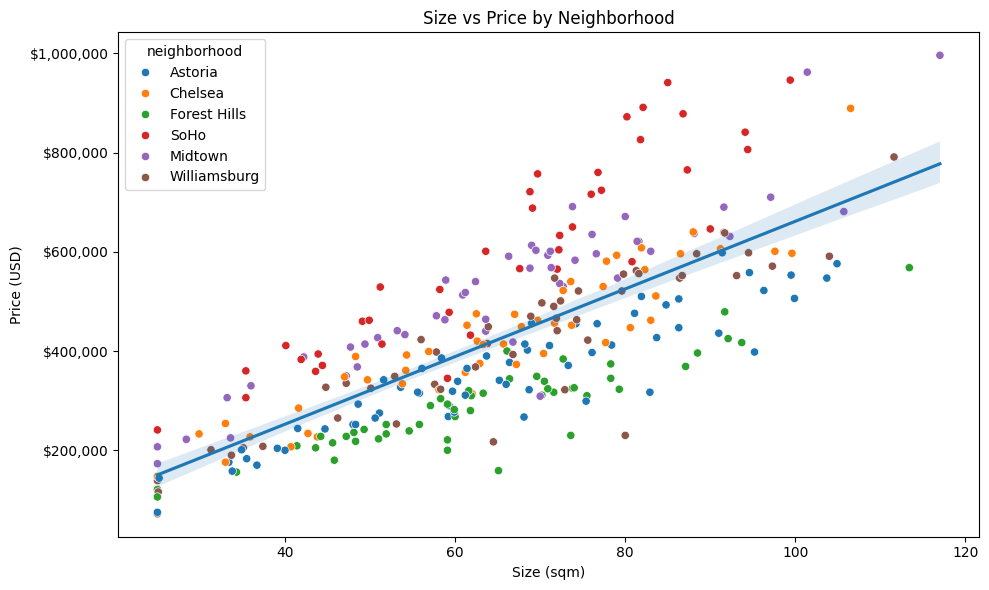

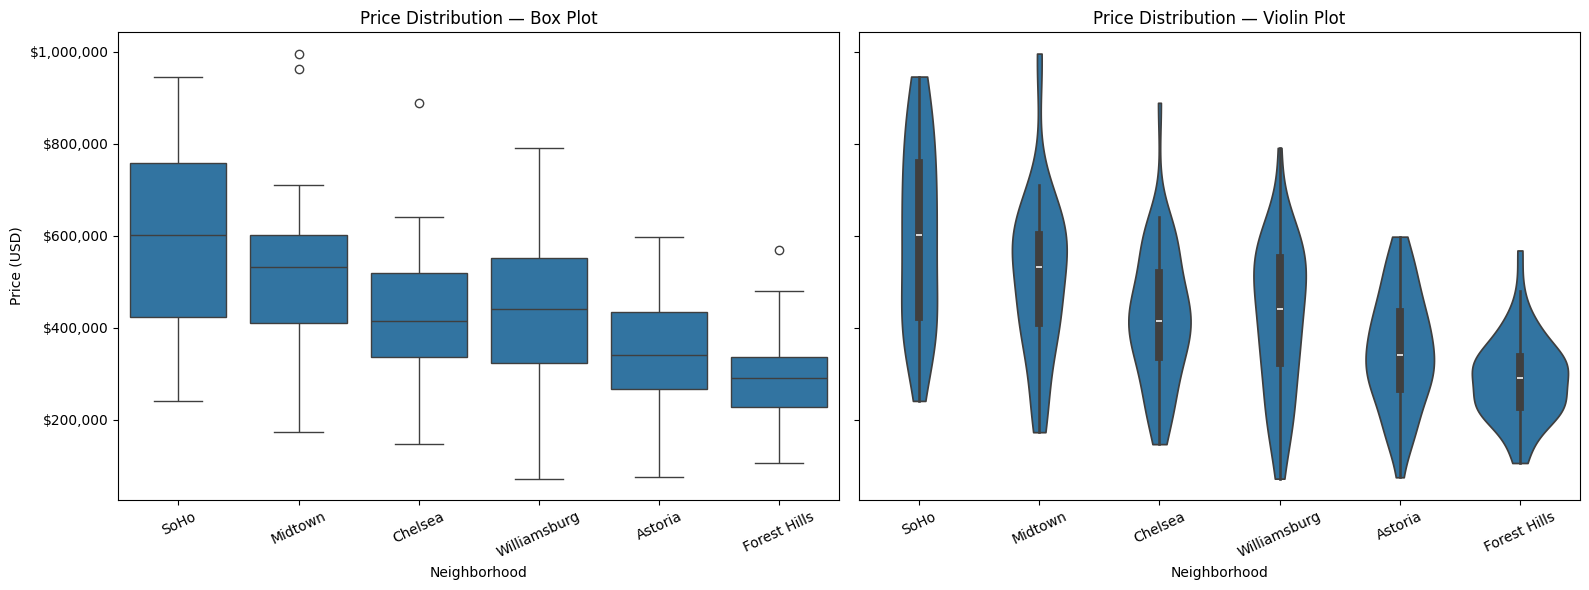

In [7]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: size vs price scatter + regression line, colored by neighborhood
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='size_sqm', y='price', hue='neighborhood', ax=ax)
sns.regplot(data=df, x='size_sqm', y='price', scatter=False, ax=ax)
ax.set_title('Size vs Price by Neighborhood')
ax.set_xlabel('Size (sqm)')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()

# Chart 2: price distribution by neighborhood (box and violin)
order = avg_price_by_neighborhood.index
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.boxplot(data=df, x='neighborhood', y='price', order=order, ax=axes[0])
axes[0].set_title('Price Distribution — Box Plot')
axes[0].set_xlabel('Neighborhood')
axes[0].set_ylabel('Price (USD)')
axes[0].tick_params(axis='x', rotation=25)

sns.violinplot(data=df, x='neighborhood', y='price', order=order, cut=0, ax=axes[1])
axes[1].set_title('Price Distribution — Violin Plot')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('Price (USD)')
axes[1].tick_params(axis='x', rotation=25)

for ax in axes:
    ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Size and price move together (correlation **0.76**).
  (면적과 가격은 같이 움직임. 상관 0.76)
- Average price runs from SoHo **$601,179** down to Forest Hills **$288,800**.
  (평균 가격은 SoHo $601,179에서 Forest Hills $288,800까지 내려감)
- After dividing by size, subway distance still matters: correlation **-0.43**.
  (면적으로 나눈 뒤에도 역까지 거리는 남아 있음. 상관 -0.43)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Price a listing from size first, because that relationship is **0.76**.
   (가격은 면적부터 보기. 그 관계가 0.76이기 때문)
2. Keep a neighborhood adjustment: SoHo averages about **$312,000** more than Forest Hills.
   (동네 보정을 두기. SoHo 평균이 Forest Hills보다 약 $312,000 높음)
3. Treat a longer walk to the subway as a discount on price per sqm (correlation **-0.43**).
   (역까지 거리가 길면 면적당 가격을 낮추는 쪽으로 보기. 상관 -0.43)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I called `pd.corr`. Correlation is a method on the column, not a function on pandas.
  (pd.corr를 호출함. 상관은 pandas 함수가 아니라 열의 메서드)
- The first charts used scientific notation (`1e6`) and listed neighborhoods in name order, not average-price order.
  (처음 차트는 y축이 1e6였고, 동네가 평균 가격 순이 아니라 이름 순이었음)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `.corr()` on a column is Pearson by default. It measures a straight-line relationship.
  (열의 .corr() 기본값은 피어슨. 직선 관계를 재는 값)
- A scatter is the right chart when many listings share a similar size. `regplot` draws the line through those points, and `hue` colors them by neighborhood.
  (비슷한 면적에 매물이 여러 건이면 산점도가 맞음. regplot은 그 점들의 선이고, hue는 동네별 색)
- A box plot compares median, middle half, and outliers. A violin plot adds where the prices pile up.
  (박스플롯은 중앙값, 가운데 절반, 이상치를 비교. 바이올린플롯은 가격이 어디에 몰리는지를 더함)
  

---
# 🧠 Reflection

**What was difficult?**
Choosing a scatter instead of a line, and reading `regplot`, `hue`, and the violin plot.
(선 대신 산점도를 고르는 것, 그리고 regplot, hue, 바이올린플롯을 읽는 것)

**Why?**
Each listing is one point, so a line would connect unrelated apartments. The new chart pieces were not in the earlier days.
(매물 한 건이 점 하나라서, 선은 서로 다른 매물을 이어 버림. 이 차트 요소는 앞날에 없었음)

**How did I solve it?**
Used `.corr()` for the strength, then a scatter plus one regression line for the direction, and a box plot beside a violin plot for the neighborhood distributions.
(세기는 .corr()로 보고, 방향은 산점도에 회귀선 하나로, 동네 분포는 박스플롯과 바이올린플롯을 나란히 봄)

**What would I do differently next time?**
Check the axis units and the category order before reading the chart.
(차트를 읽기 전에 축 단위와 범주 순서를 먼저 확인하기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Correlation, scatter, and the two distribution charts are clear.  
(상관, 산점도, 분포 차트 둘은 이해함)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★☆☆☆☆  
`regplot` and the violin plot were the new parts.  
(regplot과 바이올린플롯이 새로웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 25 — SQL window functions (Round 2/5)
  (SQL 윈도우 함수 복습)
  